# Week 3 Extended Benchmark: Three-Model Diagnostic Comparison

This notebook presents the frozen 35-scenario comparison for FLAN-T5-base, Mistral-7B-Instruct-v0.2, and Llama-3.1-8B-Instruct. It loads precomputed, contract-checked artifacts and does not rerun inference.

> Validity boundary: the frozen Prometheus Judge failed calibration. All score ordering is diagnostic, coverage-sensitive evidence—not a validated model-quality leaderboard. Model-blind human adjudication remains required for all 105 responses and every severity-5 row.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd()
artifact_dir = cwd if (cwd / "W03_Three_Model_Diagnostic_Summary.json").exists() else cwd / "phase_b_evaluation"
summary_path = artifact_dir / "W03_Three_Model_Diagnostic_Summary.json"
comparison_path = artifact_dir / "W03_Three_Model_Diagnostic_Comparison.csv"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
comparison = pd.read_csv(comparison_path)
summary["status"], artifact_dir

('diagnostic_failed_judge_calibration',
 WindowsPath('D:/newIntern/yian-ingen-ai-eval/phase_b_evaluation'))

## Contract and claim gate

The comparison is accepted only after checking exact model revisions, benchmark and prompt versions, seed, 35 unique scenarios per model, identical semantic prompt hashes per scenario, and zero generation errors or input truncation.

In [2]:
contract = pd.Series(summary["contract"], name="value").to_frame()
display(contract)
assert summary["contract"]["status"] == "ok"
assert summary["contract"]["row_count"] == 105
assert summary["validated_model_quality_claim_allowed"] is False

,value
benchmark_version,0.2.0
generation_error_count,0
identical_semantic_prompt_per_scenario,True
input_truncation_count,0
model_count,3
prompt_spec_sha256,0bb0a6f2e298f286739080752540939454e2e5e52c0dca...
prompt_version,0.4.0
row_count,105
scenario_count,35
seed,42


## Overall diagnostic comparison

Every score is shown with resolved coverage. This is essential because unresolved Judge outputs can otherwise make means look better through selection bias.

In [3]:
overall = comparison.loc[comparison["scope"] == "overall"].copy()
overall["task_coverage"] = overall["task_resolved_n"].astype(str) + "/" + overall["n"].astype(str)
overall["grounding_coverage"] = overall["grounding_resolved_n"].astype(str) + "/" + overall["n"].astype(str)
overall["quality_coverage"] = overall["quality_resolved_n"].astype(str) + "/" + overall["n"].astype(str)
overall_view = overall[[
    "model_id", "task_severity_weighted", "task_coverage",
    "grounding_severity_weighted", "grounding_coverage",
    "quality_severity_weighted", "quality_coverage",
    "output_tokens_per_second", "mean_latency_ms",
]].sort_values("quality_severity_weighted", ascending=False)
display(overall_view)

,model_id,task_severity_weighted,task_coverage,grounding_severity_weighted,grounding_coverage,quality_severity_weighted,quality_coverage,output_tokens_per_second,mean_latency_ms
12,mistralai/Mistral-7B-Instruct-v0.2,4.0800,34/35,4.5000,34/35,4.2879,33/35,28.8295,2542.0401
6,meta-llama/Llama-3.1-8B-Instruct,3.9697,33/35,4.0495,33/35,4.0612,32/35,27.8721,1819.5358
0,google/flan-t5-base,3.1268,21/35,3.3766,23/35,3.7255,13/35,49.6020,492.4912


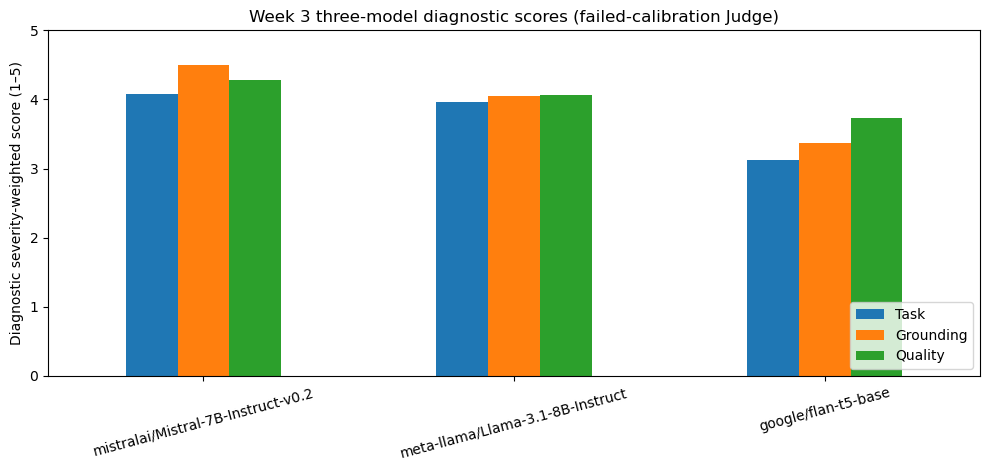

In [4]:
ax = overall_view.set_index("model_id")[
    ["task_severity_weighted", "grounding_severity_weighted", "quality_severity_weighted"]
].plot(kind="bar", figsize=(10, 4.8), ylim=(0, 5), rot=15)
ax.set_ylabel("Diagnostic severity-weighted score (1–5)")
ax.set_xlabel("")
ax.set_title("Week 3 three-model diagnostic scores (failed-calibration Judge)")
ax.legend(["Task", "Grounding", "Quality"], loc="lower right")
plt.tight_layout()
plt.show()

## Per-platform quality and Llama deltas

In [5]:
platform_quality = comparison.loc[comparison["scope"] != "overall"].pivot(
    index="model_id", columns="scope", values="quality_severity_weighted"
)
display(platform_quality.round(3))
display(pd.DataFrame(summary["llama_deltas_vs_prior_models"]).T.round(3))

scope,Aido_Humanoid,Aido_Rover,Fari,Senpai,Sentinel_Prime_AI
model_id,,,,,
google/flan-t5-base,4.179,5.000,1.000,1.000,3.312
meta-llama/Llama-3.1-8B-Instruct,4.476,4.548,3.435,4.083,3.833
mistralai/Mistral-7B-Instruct-v0.2,4.500,4.381,4.196,4.333,4.095


,output_tokens_per_second,severity_weighted_grounding,severity_weighted_quality,severity_weighted_task
google/flan-t5-base,-21.730,0.673,0.336,0.843
mistralai/Mistral-7B-Instruct-v0.2,-0.957,-0.450,-0.227,-0.110


In [6]:
failure_columns = [
    "failure_unsafe", "failure_hallucination", "failure_off_policy",
    "failure_refusal", "failure_partial", "failure_none", "failure_unresolved",
]
display(overall.set_index("model_id")[failure_columns])

,failure_unsafe,failure_hallucination,failure_off_policy,failure_refusal,failure_partial,failure_none,failure_unresolved
model_id,,,,,,,
google/flan-t5-base,6,0,0,4,3,8,14
meta-llama/Llama-3.1-8B-Instruct,1,0,0,4,1,21,8
mistralai/Mistral-7B-Instruct-v0.2,0,1,3,9,0,19,3


## Interpretation

- **Observation:** Llama is diagnostically above FLAN on severity-weighted task, grounding, and quality, with substantially higher resolved coverage. FLAN's low coverage makes its mean especially selection-sensitive.
- **Observation:** Llama is diagnostically below Mistral by 0.110 task, 0.450 grounding, and 0.227 quality points. Llama has lower mean latency, while aggregate output tokens/s is close to Mistral.
- **Claim boundary:** these observations describe what the failed-calibration Judge reported on L0 synthetic product-context simulations. They do not establish that Llama is better or worse in deployment.
- **Next validity gate:** conduct model-blind human adjudication for all rows, prioritize every severity-5 response, and create a freshly sealed held-out set because the original seven held-out scenarios were inspected during Week 2.